In [ ]:
# Настройка путей 
import sys
from pathlib import Path

# Получаем путь к корню проекта: поднимаемся из "Jupyter Notebooks/" на уровень выше
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query


In [3]:
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "third_wave_coffee_shop.csv", parse_dates=['datetime', 'sale_date'])

In [5]:
# базовый осмотр
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  4943 non-null   object        
 1   customer_id     4943 non-null   object        
 2   sale_date       4943 non-null   datetime64[ns]
 3   sale_time       4943 non-null   object        
 4   day_of_week     4943 non-null   int64         
 5   day_name        4943 non-null   object        
 6   is_weekend      4943 non-null   bool          
 7   coffee_name     4943 non-null   object        
 8   drink_price     4943 non-null   float64       
 9   total_cost      4943 non-null   float64       
 10  payment_method  4943 non-null   object        
 11  datetime        4943 non-null   datetime64[ns]
 12  time_of_day     4943 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 468.4+ KB


(  transaction_id customer_id  sale_date sale_time  day_of_week day_name  \
 0        TX_0125   CUST_6596 2025-07-01  08:24:55            2  Tuesday   
 1        TX_0125   CUST_6596 2025-07-01  08:24:55            2  Tuesday   
 2        TX_1977   CUST_4044 2025-07-01  08:42:32            2  Tuesday   
 3        TX_3011   CUST_2256 2025-07-01  08:43:55            2  Tuesday   
 4        TX_3392   CUST_6082 2025-07-01  08:44:55            2  Tuesday   
 
    is_weekend     coffee_name  drink_price  total_cost payment_method  \
 0       False      Cappuccino        320.0       640.0           card   
 1       False      Cappuccino        320.0       640.0           card   
 2       False           Latte        340.0       340.0           card   
 3       False  Latte with add        440.0       440.0           cash   
 4       False  Latte with add        440.0       760.0           card   
 
              datetime time_of_day  
 0 2025-07-01 08:24:55     Morning  
 1 2025-07-01 08:24:55

**Универсальная функция предобработки**

In [6]:
print(df.columns.tolist())

['transaction_id', 'customer_id', 'sale_date', 'sale_time', 'day_of_week', 'day_name', 'is_weekend', 'coffee_name', 'drink_price', 'total_cost', 'payment_method', 'datetime', 'time_of_day']


#### KPI кофейни 

In [7]:
def kpi_summary(df):
    return {
        "Total Revenue": df.groupby("transaction_id")["total_cost"].first().sum(),
        "Transactions": df["transaction_id"].nunique(),
        "Avg Ticket": df.groupby("transaction_id")["drink_price"].sum().mean()
    }

kpi_summary(df)

# С удаление дубликатов "total_cost" в чеке.
# "Total Revenue": df.drop_duplicates("transaction_id")["total_cost"].sum()

{'Total Revenue': np.float64(1668050.0),
 'Transactions': 3547,
 'Avg Ticket': np.float64(470.2706512545813)}

In [8]:
df_test = df.copy()
def kpi_summary_report(df_frame):
    data = {
        "Total Revenue": df.groupby("transaction_id")["total_cost"].first().sum(),
        "Transactions": df["transaction_id"].nunique(),
        "Avg Ticket": df.groupby("transaction_id")["drink_price"].sum().mean()
    }
    # Превращаем в Series
    return pd.Series(data, name="KPI_Value")

# Без экспоненты
pd.set_option('display.float_format', '{:,.2f}'.format)

print(kpi_summary_report(df_test))

Total Revenue   1,668,050.00
Transactions        3,547.00
Avg Ticket            470.27
Name: KPI_Value, dtype: float64


In [9]:
def kpi_summary_table(df_frame):
    data = {
        "Total Revenue": [df.groupby("transaction_id")["total_cost"].first().sum()],
        "Transactions": [df["transaction_id"].nunique()],
        "Avg Ticket": [df.groupby("transaction_id")["drink_price"].sum().mean()]
    }
    return pd.DataFrame(data)

report_df = kpi_summary_table(df_test)
report_df

,Total Revenue,Transactions,Avg Ticket
0,"1,668,050.00",3547,470.27


#### Анализ продаж по продуктам (Menu Engineering)

In [10]:
# Топ и анти-топ продуктов
def product_sales(df):
    return (
        df.groupby("coffee_name")
        .agg(
            revenue=("drink_price", "sum"),             # сумма цен всех позиций этого напитка
            quantity=("coffee_name", "count"),          # количество заказанных напитков = число строк
            transactions=("transaction_id", "nunique")  # в скольких чеках встречался
        )
        .sort_values("revenue", ascending=False)
        .reset_index()
    )

top_products = product_sales(df)
top_products

,coffee_name,revenue,quantity,transactions
0,Cappuccino,"372,800.00",1165,1062
1,Latte,"354,280.00",1042,972
2,Latte with add,"326,920.00",743,708
3,Batch brew,"202,560.00",844,795
4,Raf coffee,"143,640.00",342,338
5,Flat white,"113,900.00",335,332
6,Warming drinks (tea),"106,800.00",267,258
7,Espresso,"47,150.00",205,202


In [11]:
# Добавление месяца и часа (если нужно для группировки)
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
# df['date'] = df['datetime'].dt.date
display(df[['datetime', 'month', 'hour']].head())

,datetime,month,hour
0,2025-07-01 08:24:55,7,8
1,2025-07-01 08:24:55,7,8
2,2025-07-01 08:42:32,7,8
3,2025-07-01 08:43:55,7,8
4,2025-07-01 08:44:55,7,8


#### ABC-анализ (фокус на выручку)

*Понимание, на какие 20% напитков приходится 80% выручки → фокус для маркетинга, персонала, закупок.*

In [12]:
def abc_analysis(df):
    # 1. Группируем по напиткам и считаем выручку
    abc = (
        df.groupby("coffee_name")["drink_price"]
          .sum()
          .sort_values(ascending=False)
          .reset_index(name="revenue")  # явно указываем имя агрегированной колонки
    )
    
    # 2. Считаем доли и кумулятивную долю
    abc["revenue_share"] = abc["revenue"] / abc["revenue"].sum()
    abc["cumulative_share"] = abc["revenue_share"].cumsum()
    
    # 3. Присваиваем ABC-классы
    # np.select (NumPy) — это как продвинутый if-elif-else
    abc["ABC_class"] = np.select(
        condlist=[
            abc["cumulative_share"] <= 0.75,
            abc["cumulative_share"] <= 0.95
        ],
        choicelist=["A", "B"],
        default="C"  # всего 5% денег (но товаров может быть очень много)

    )
    
    return abc

abc_analysis(df).head(10)

,coffee_name,revenue,revenue_share,cumulative_share,ABC_class
0,Cappuccino,"372,800.00",0.22,0.22,A
1,Latte,"354,280.00",0.21,0.44,A
2,Latte with add,"326,920.00",0.20,0.63,A
3,Batch brew,"202,560.00",0.12,0.75,B
4,Raf coffee,"143,640.00",0.09,0.84,B
5,Flat white,"113,900.00",0.07,0.91,B
6,Warming drinks (tea),"106,800.00",0.06,0.97,C
7,Espresso,"47,150.00",0.03,1.00,C


In [13]:
def color_abc(row):
    # Определяем цвет фона в зависимости от класса
    if row["ABC_class"] == "A":
        color = "#c7e9c0" # Нежно-зеленый
    elif row["ABC_class"] == "B":
        color = "#fff3b0" # Нежно-желтый
    else:
        color = "#ffcccc" # Нежно-красный
    
    # Возвращаем стиль для всей строки
    return [f"background-color: {color}"] * len(row)

abc_result = abc_analysis(df)

# 2. Применяем раскраску и форматирование чисел
styled_abc = (
    abc_result.style
    .apply(color_abc, axis=1) # axis=1 значит "красить по строкам"
    .format({
        "revenue": "{:,.2f}",
        "revenue_share": "{:.2%}",      # Показываем как проценты: 0.15 -> 15.00%
        "cumulative_share": "{:.2%}"
    })
)

styled_abc


,coffee_name,revenue,revenue_share,cumulative_share,ABC_class
0,Cappuccino,"372,800.00",22.35%,22.35%,A
1,Latte,"354,280.00",21.24%,43.59%,A
2,Latte with add,"326,920.00",19.60%,63.19%,A
3,Batch brew,"202,560.00",12.14%,75.33%,B
4,Raf coffee,"143,640.00",8.61%,83.94%,B
5,Flat white,"113,900.00",6.83%,90.77%,B
6,Warming drinks (tea),"106,800.00",6.40%,97.17%,C
7,Espresso,"47,150.00",2.83%,100.00%,C


#### Временной анализ (нагрузка и планирование персонала)

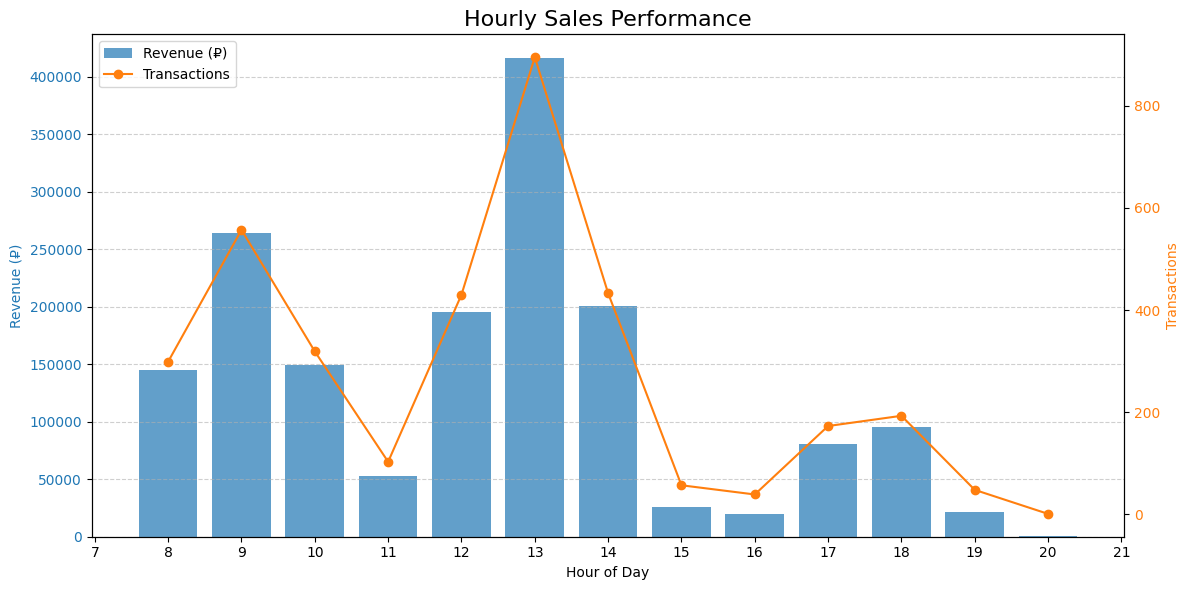

,hour,revenue,transactions,items_sold
0,8,"145,040.00",299,427
1,9,"263,820.00",557,792
2,10,"149,750.00",319,449
3,11,"52,650.00",103,159
4,12,"195,630.00",430,572
5,13,"416,210.00",895,1235
6,14,"201,050.00",433,593
7,15,"25,910.00",57,76
8,16,"19,800.00",39,57
9,17,"80,740.00",173,242


In [14]:

# 1. Агрегация по часам
hourly_sales = (
    df.groupby("hour", as_index=False)
      .agg(
          revenue=("drink_price", "sum"),
          transactions=("transaction_id", "nunique"),
          items_sold=("coffee_name", "count")  # количество напитков
      )
      .sort_values("hour")  
)

# 2. Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы: выручка
color = "tab:blue"
ax1.bar(hourly_sales["hour"], hourly_sales["revenue"], color=color, alpha=0.7, label="Revenue (₽)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Revenue (₽)", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticks(range(0, 24))
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Добавим вторую ось для количества чеков (необязательно, но полезно)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.plot(hourly_sales["hour"], hourly_sales["transactions"], 
         color=color, marker="o", linestyle="-", label="Transactions")
ax2.set_ylabel("Transactions", color=color)
ax2.tick_params(axis="y", labelcolor=color)

# Заголовок и легенда
plt.title("Hourly Sales Performance", fontsize=16)
fig.tight_layout()

# Объединённая легенда
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.show()

# Выведем таблицу для точности
hourly_sales

#### Анализ дней недели


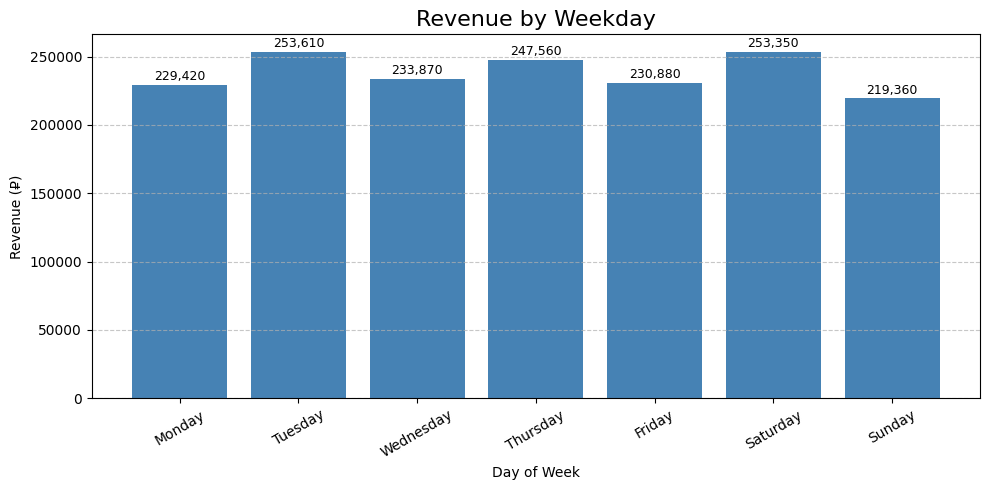

,day_name,revenue,transactions,items,avg_ticket
0,Monday,"229,420.00",492,675,566.21
1,Tuesday,"253,610.00",538,755,578.20
2,Wednesday,"233,870.00",486,695,586.39
3,Thursday,"247,560.00",524,732,573.17
4,Friday,"230,880.00",496,698,569.90
5,Saturday,"253,350.00",517,738,604.21
6,Sunday,"219,360.00",494,650,536.46


In [15]:
# Гарантируем порядок дней
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Агрегация по дням недели
weekday_sales = (
    df.groupby("day_name", as_index=False)
      .agg(revenue=("drink_price", "sum"),
           transactions=("transaction_id", "nunique"),
           items=("coffee_name", "count"),
           avg_ticket=("total_cost", "mean")
      )  
      .round(2)  
      .set_index("day_name")
      .reindex(days_order, fill_value=0)  # ← fill_value=0 — чтобы избежать NaN
      .reset_index()
)

# Визуализация
plt.figure(figsize=(10, 5))
bars = plt.bar(weekday_sales["day_name"], weekday_sales["revenue"], color="steelblue")
plt.title("Revenue by Weekday", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Revenue (₽)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Добавим подписи значений сверху
for bar, rev in zip(bars, weekday_sales["revenue"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + rev * 0.005,
             f"{rev:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

weekday_sales

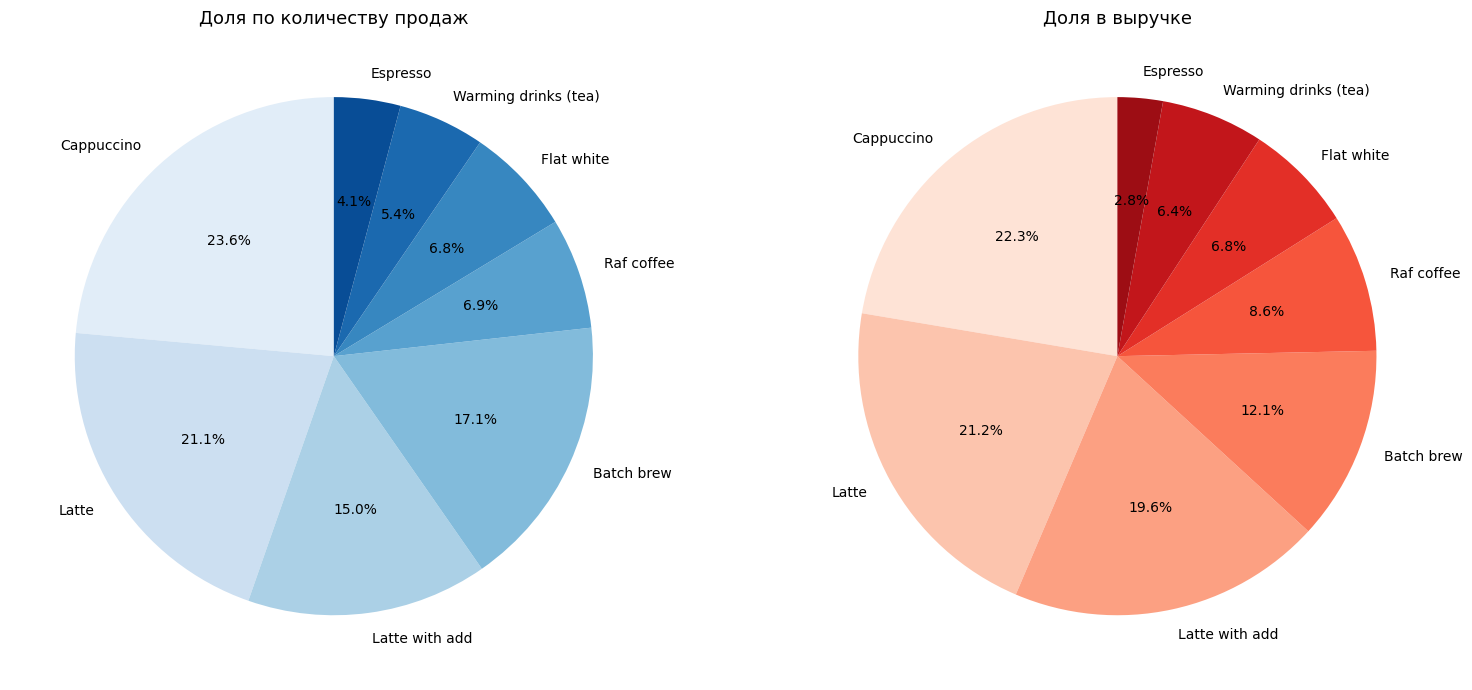

In [16]:
# Подготовка данных
coffee_stats = df.groupby('coffee_name').agg(
    drinks_sold=('coffee_name', 'count'),
    revenue=('drink_price', 'sum')
).round(2).reset_index()

coffee_stats = coffee_stats.sort_values('revenue', ascending=False).head(8)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Доля по количеству
axes[0].pie(
    coffee_stats['drinks_sold'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Blues", len(coffee_stats)),
    startangle=90
)
axes[0].set_title('Доля по количеству продаж', fontsize=13)

# 2. Доля по выручке
axes[1].pie(
    coffee_stats['revenue'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Reds", len(coffee_stats)),
    startangle=90
)
axes[1].set_title('Доля в выручке', fontsize=13)

plt.tight_layout()
plt.show()

#### **Продажи напитков по неделям** с детализацией **по каждому напитку**

*   количество проданных единиц (`units_sold`);
*   общее количество напитков за неделю (`total_units_week`)
*   процент вклада каждого напитка в общую структуру продаж (`precentage`).

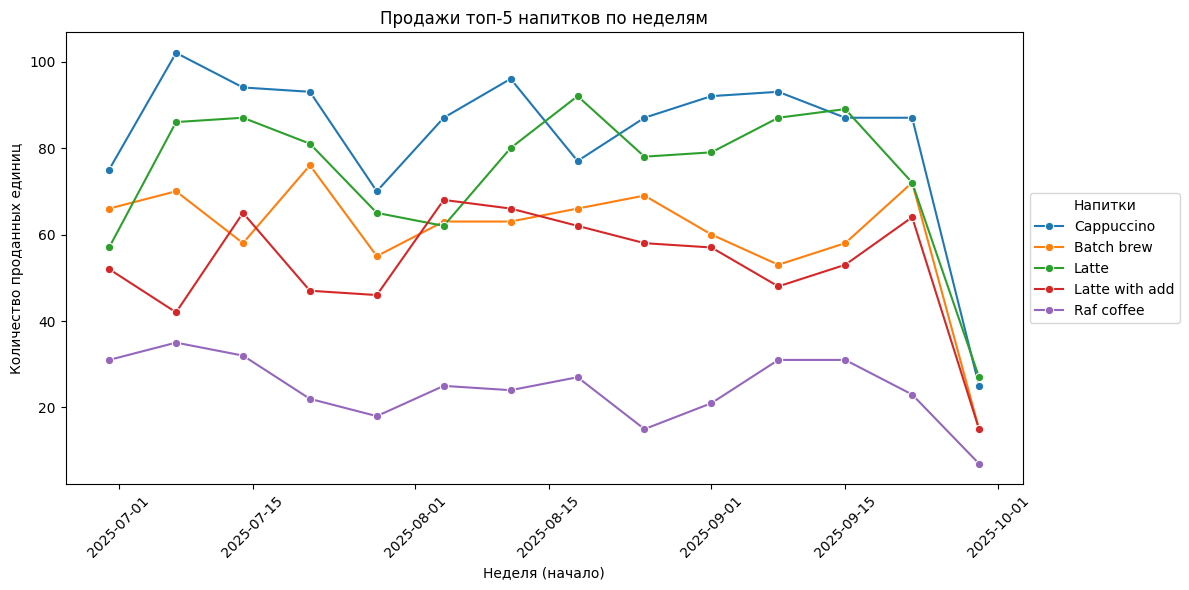

,week_start,coffee_name,units_sold,total_units_week,percentage
0,2025-06-30,Cappuccino,75,341,21.99
1,2025-06-30,Batch brew,66,341,19.35
2,2025-06-30,Latte,57,341,16.72
3,2025-06-30,Latte with add,52,341,15.25
4,2025-06-30,Raf coffee,31,341,9.09
5,2025-06-30,Flat white,25,341,7.33
6,2025-06-30,Warming drinks (tea),20,341,5.87
7,2025-06-30,Espresso,15,341,4.40
8,2025-07-07,Cappuccino,102,400,25.50
9,2025-07-07,Latte,86,400,21.50


In [17]:
# 1 Определяем начало недели (понедельник) для  каждой строки
df['week_start'] = df['sale_date'].dt.to_period('W').dt.start_time

# 2. Группируем по неделе и названию напитка → считаем количество продаж
weekly_drink_sales = (
    df
    .groupby(['week_start', 'coffee_name'])
    .size()
    .reset_index(name='units_sold')
)    

# 3. Считаем общее число напитков за каждую неделю
weekly_totals = (
    weekly_drink_sales
    .groupby('week_start')['units_sold']
    .sum()
    .reset_index(name='total_units_week')
)

# 4. Объединяем и считаем процент
result = weekly_drink_sales.merge(weekly_totals, on='week_start')
result['percentage'] = (result['units_sold'] / result['total_units_week'] * 100).round(2)

# 5. Сортируем: по неделе, затем по объёму продаж (убывание)
result = result.sort_values(['week_start', 'units_sold'], ascending=[True, False]).reset_index(drop=True)

# Топ-5 напитков за все время (для фильтрации шума)
top_drinks = df['coffee_name'].value_counts().head(5).index
result_top = result[result['coffee_name'].isin(top_drinks)]


# Построение графика
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=result_top,
    x='week_start',
    y='units_sold',
    hue='coffee_name',
    marker='o'
)
plt.title('Продажи топ-5 напитков по неделям')
plt.xlabel('Неделя (начало)')
plt.ylabel('Количество проданных единиц')
plt.xticks(rotation=45)

# Легенда за пределы графика
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    title='Напитки',        # Заголовок легенды
    frameon=True            # Рамка
)

plt.tight_layout()
plt.show()


# Показываем результат
display(result.head(16))


#### rolling_mean_7d

**Цель — трехступенчатый процесс:**

`Шаг 1:` Найти уникальные чеки и их стоимость. Нужно получить таблицу, где каждая строка - это один уникальный чек (**transaction_id**) и его сумма (**total_cost**).

`Шаг 2:` Сложить стоимость этих уникальных чеков по дням. Нужно взять результат` Шага 1` и сгруппировать его по дате, чтобы получить правильную дневную выручку (daily_revenue).

`Шаг 3:` Применить оконную функцию. Нужно взять результат `Шага 2` и посчитать для него скользящее среднее.

In [18]:
# Unique transactions
unique_transactions = (
    df.groupby(["sale_date", "transaction_id"], as_index=False)
        .agg(transaction_revenue=("total_cost", "max"))
)

# Daily aggregation
daily_agg = (
    unique_transactions.groupby("sale_date", as_index=False)
    .agg(daily_revenue=("transaction_revenue", "sum"))
)

# Rolling mean
daily_agg["rolling_mean_7d"] = (
    daily_agg["daily_revenue"]
    .rolling(window=7, min_periods=7)
    .mean()
)


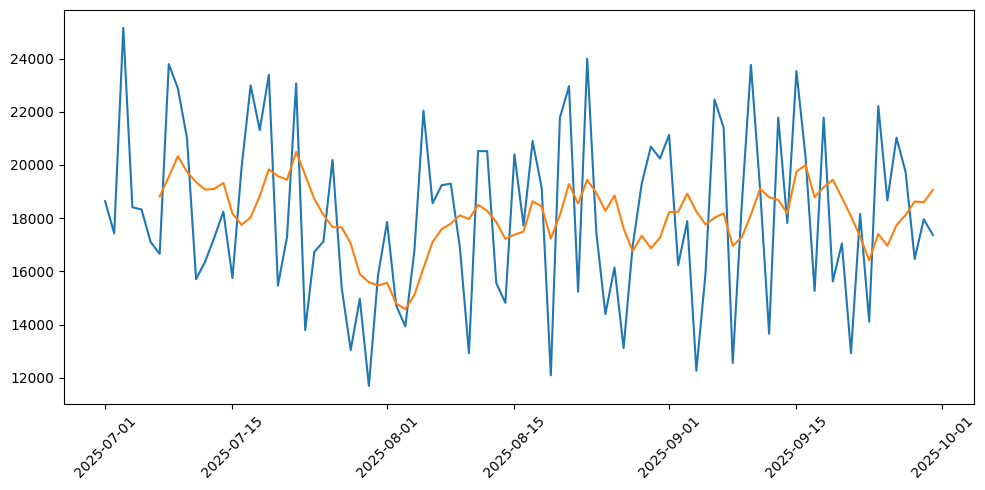

,sale_date,daily_revenue,rolling_mean_7d
0,2025-07-01,"18,640.00",NaN
1,2025-07-02,"17,430.00",NaN
2,2025-07-03,"25,150.00",NaN
3,2025-07-04,"18,410.00",NaN
4,2025-07-05,"18,330.00",NaN
5,2025-07-06,"17,110.00",NaN
6,2025-07-07,"16,660.00","18,818.57"
7,2025-07-08,"23,790.00","19,554.29"
8,2025-07-09,"22,880.00","20,332.86"
9,2025-07-10,"21,010.00","19,741.43"


In [19]:
# Plot
plt.figure()
plt.plot(daily_agg["sale_date"], daily_agg["daily_revenue"])
plt.plot(daily_agg["sale_date"], daily_agg["rolling_mean_7d"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_agg.head(32)